# Recommendation System Project: IBM Community

In this notebook, you will be putting your recommendation skills to use on real data from the IBM Watson Studio platform. 


You may either submit your notebook through the workspace here, or you may work from your local machine and submit through the next page.  Either way assure that your code passes the project [RUBRIC](https://review.udacity.com/#!/rubrics/3325/view).  **Please save regularly.**

By following the table of contents, you will build out a number of different methods for making recommendations that can be used for different situations. 


## Table of Contents

I. [Exploratory Data Analysis](#Exploratory-Data-Analysis)<br>
II. [Rank Based Recommendations](#Rank)<br>
III. [User-User Based Collaborative Filtering](#User-User)<br>
IV. [Content Based Recommendations](#Content-Recs)<br>
V. [Matrix Factorization](#Matrix-Fact)<br>
VI. [Extras & Concluding](#conclusions)

At the end of the notebook, you will find directions for how to submit your work.  Let's get started by importing the necessary libraries and reading in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import project_tests as t


df = pd.read_csv('data/user-item-interactions.csv')
# Show df to get an idea of the data
df.head()

,Unnamed: 0,article_id,title,email
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",ef5f11f77ba020cd36e1105a00ab868bbdbf7fe7
1,1,1314.0,healthcare python streaming application demo,083cbdfa93c8444beaa4c5f5e0f5f9198e4f9e0b
2,2,1429.0,use deep learning for image classification,b96a4f2e92d8572034b1e9b28f9ac673765cd074
3,3,1338.0,ml optimization using cognitive assistant,06485706b34a5c9bf2a0ecdac41daf7e7654ceb7
4,4,1276.0,deploy your python model as a restful api,f01220c46fc92c6e6b161b1849de11faacd7ccb2


### <a class="anchor" id="Exploratory-Data-Analysis">Part I : Exploratory Data Analysis</a>

Use the dictionary and cells below to provide some insight into the descriptive statistics of the data.

`1.` Are there any missing values? If so, provide a count of missing values. If there are missing values in `email`, assign it the same id value `"unknown_user"`.

In [2]:
# Some interactions do not have a user associated with it, assume the same user.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45993 entries, 0 to 45992
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  45993 non-null  int64  
 1   article_id  45993 non-null  float64
 2   title       45993 non-null  object 
 3   email       45976 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.4+ MB


In [3]:
print(f"Number of Null email values is: ")

Number of Null email values is: 


In [4]:
df[df.email.isna()]

,Unnamed: 0,article_id,title,email
25131,25146,1016.0,why you should master r (even if it might even...,NaN
29758,30157,1393.0,the nurse assignment problem,NaN
29759,30158,20.0,working interactively with rstudio and noteboo...,NaN
29760,30159,1174.0,breast cancer wisconsin (diagnostic) data set,NaN
29761,30160,62.0,data visualization: the importance of excludin...,NaN
35264,36016,224.0,"using apply, sapply, lapply in r",NaN
35276,36029,961.0,beyond parallelize and collect,NaN
35277,36030,268.0,sector correlations shiny app,NaN
35278,36031,268.0,sector correlations shiny app,NaN
35279,36032,268.0,sector correlations shiny app,NaN


In [5]:
# Fill email NaNs with "unknown_user"
df['email'] = df['email'].fillna('unknown_user')

In [6]:
# Check if no more NaNs 
df[df.email.isna()]

,Unnamed: 0,article_id,title,email


`2.` What is the distribution of how many articles a user interacts with in the dataset?  Provide a visual and descriptive statistics to assist with giving a look at the number of times each user interacts with an article.

In [7]:
# What are the descriptive statistics of the number of articles a user interacts with?
user_interactions = df.groupby('email')['article_id'].count()
user_interactions.describe()

count    5149.000000
mean        8.932414
std        16.801011
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       364.000000
Name: article_id, dtype: float64

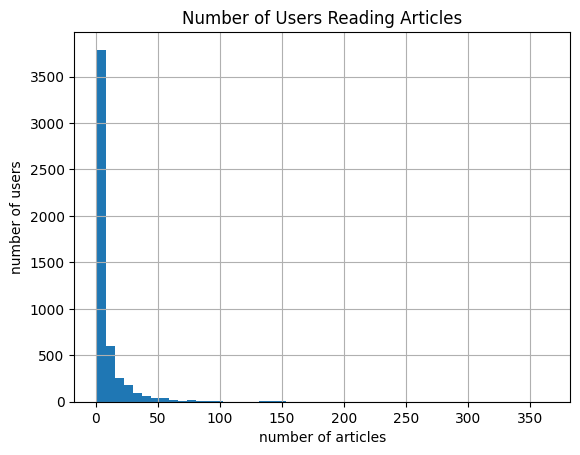

In [8]:
# Create a plot of the number of articles read by each user
user_interactions = df.groupby('email')['article_id'].count()
user_interactions.hist(bins=50)
plt.xlabel('number of articles')
plt.ylabel('number of users')
plt.title('Number of Users Reading Articles')
plt.show()

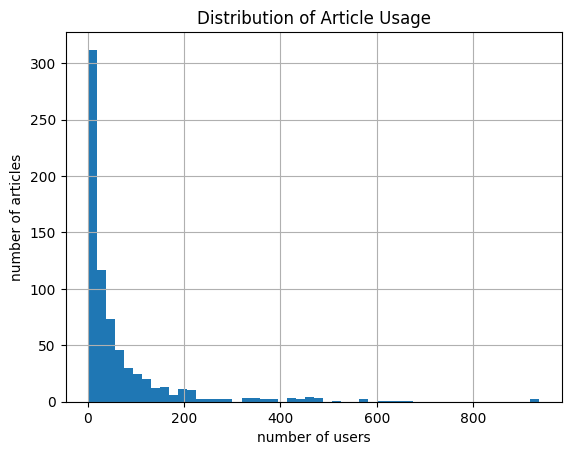

In [9]:
# Create a plot of the number of times each article was read
article_interactions = df.groupby('article_id')['email'].count()
article_interactions.hist(bins=50)
plt.xlabel('number of users')
plt.ylabel('number of articles')
plt.title('Distribution of Article Usage')
plt.show()

In [10]:
# Fill in the median and maximum number of user_article interactions below
user_interactions = df.groupby('email')['article_id'].count()
median_val = int(user_interactions.median())  # 50% of individuals interact with ____ number of articles or fewer.
max_views_by_user = int(user_interactions.max())  # The maximum number of user-article interactions by any 1 user is ______.

`3.` Use the cells below to find:

**a.** The number of unique articles that have an interaction with a user.  
**b.** The number of unique articles in the dataset (whether they have any interactions or not).<br>
**c.** The number of unique users in the dataset. (excluding null values) <br>
**d.** The number of user-article interactions in the dataset.

In [11]:
unique_articles = df['article_id'].nunique()  # The number of unique articles that have at least one interaction
total_articles = df['article_id'].nunique()  # The number of unique articles on the IBM platform
unique_users = df['email'].nunique()  # The number of unique users
user_article_interactions = len(df)  # The number of user-article interactions

`4.` Use the cells below to find the most viewed **article_id**, as well as how often it was viewed.  After talking to the company leaders, the `email_mapper` function was deemed a reasonable way to map users to ids.  There were a small number of null values, and it was found that all of these null values likely belonged to a single user (which is how they are stored using the function below).

In [12]:
article_view_counts = df.groupby('article_id')['email'].count().sort_values(ascending=False)
most_viewed_article_id = str(int(article_view_counts.index[0]))  # The most viewed article in the dataset as a string
max_views = int(article_view_counts.values[0])  # The most viewed article in the dataset was viewed how many times?

In [13]:
## No need to change the code here - this will be helpful for later parts of the notebook
# Run this cell to map the user email to a user_id column and remove the email column

def email_mapper(df=df):
    coded_dict = {
        email: num 
        for num, email in enumerate(df['email'].unique(), start=1)
    }
    return [coded_dict[val] for val in df['email']]

df['user_id'] = email_mapper(df)
del df['email']

# show header
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",1
1,1,1314.0,healthcare python streaming application demo,2
2,2,1429.0,use deep learning for image classification,3
3,3,1338.0,ml optimization using cognitive assistant,4
4,4,1276.0,deploy your python model as a restful api,5


In [14]:
## If you stored all your results in the variable names above, 
## you shouldn't need to change anything in this cell

sol_1_dict = {
    '`50% of individuals have _____ or fewer interactions.`': median_val,
    '`The total number of user-article interactions in the dataset is ______.`': user_article_interactions,
    '`The maximum number of user-article interactions by any 1 user is ______.`': max_views_by_user,
    '`The most viewed article in the dataset was viewed _____ times.`': max_views,
    '`The article_id of the most viewed article is ______.`': most_viewed_article_id,
    '`The number of unique articles that have at least 1 rating ______.`': unique_articles,
    '`The number of unique users in the dataset is ______`': unique_users,
    '`The number of unique articles on the IBM platform`': total_articles
}

# Test your dictionary against the solution
t.sol_1_test(sol_1_dict)

It looks like you have everything right here! Nice job!


### <a class="anchor" id="Rank">Part II: Rank-Based Recommendations</a>

In this project, we don't actually have ratings for whether a user liked an article or not.  We only know that a user has interacted with an article. In these cases, the popularity of an article can really only be based on how often an article was interacted with.

`1.` Fill in the function below to return the **n** top articles ordered with most interactions as the top. Test your function using the tests below.

In [15]:
def get_top_articles(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    
    """
    article_counts = df.groupby(['article_id', 'title']).size().reset_index(name='count')
    top_articles_df = article_counts.sort_values('count', ascending=False).head(n)
    top_articles = top_articles_df['title'].tolist()
    
    return top_articles # Return the top article titles from df

def get_top_article_ids(n, df=df):
    """
    INPUT:
    n - (int) the number of top articles to return
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    top_articles - (list) A list of the top 'n' article titles 
    
    """
    article_counts = df.groupby('article_id').size().reset_index(name='count')
    top_articles_df = article_counts.sort_values('count', ascending=False).head(n)
    top_articles = top_articles_df['article_id'].tolist()
 
    return top_articles # Return the top article ids

In [16]:
print(get_top_articles(10))
print(get_top_article_ids(10))

['use deep learning for image classification', 'insights from new york car accident reports', 'visualize car data with brunel', 'use xgboost, scikit-learn & ibm watson machine learning apis', 'predicting churn with the spss random tree algorithm', 'healthcare python streaming application demo', 'finding optimal locations of new store using decision optimization', 'apache spark lab, part 1: basic concepts', 'analyze energy consumption in buildings', 'gosales transactions for logistic regression model']
[1429.0, 1330.0, 1431.0, 1427.0, 1364.0, 1314.0, 1293.0, 1170.0, 1162.0, 1304.0]


In [17]:
# Test your function by returning the top 5, 10, and 20 articles
top_5 = get_top_articles(5)
top_10 = get_top_articles(10)
top_20 = get_top_articles(20)

# Test each of your three lists from above
t.sol_2_test(get_top_articles)

Your top_5 looks like the solution list! Nice job.
Your top_10 looks like the solution list! Nice job.
Your top_20 looks like the solution list! Nice job.


### <a class="anchor" id="User-User">Part III: User-User Based Collaborative Filtering</a>


`1.` Use the function below to reformat the **df** dataframe to be shaped with users as the rows and articles as the columns.  

* Each **user** should only appear in each **row** once.


* Each **article** should only show up in one **column**.  


* **If a user has interacted with an article, then place a 1 where the user-row meets for that article-column**.  It does not matter how many times a user has interacted with the article, all entries where a user has interacted with an article should be a 1.  


* **If a user has not interacted with an item, then place a zero where the user-row meets for that article-column**. 

Use the tests to make sure the basic structure of your matrix matches what is expected by the solution.

In [18]:
# create the user-article matrix with 1's and 0's

def create_user_item_matrix(df, fill_value=0):
    """
    INPUT:
    df - pandas dataframe with article_id, title, user_id columns
    
    OUTPUT:
    user_item - user item matrix 
    
    Description:
    Return a matrix with user ids as rows and article ids on the columns with 1 values where a user interacted with 
    an article and a 0 otherwise
    """
    # Fill in the function here
    user_item = df.groupby(['user_id', 'article_id'])['title'].count().unstack(fill_value=fill_value)
    user_item = (user_item > 0).astype(int)
    
    return user_item # return the user_item matrix 

user_item = create_user_item_matrix(df)

In [19]:
## Tests: You should just need to run this cell.  Don't change the code.
assert user_item.shape[0] == 5149, "Oops!  The number of users in the user-article matrix doesn't look right."
assert user_item.shape[1] == 714, "Oops!  The number of articles in the user-article matrix doesn't look right."
assert user_item.sum(axis=1)[1] == 36, "Oops!  The number of articles seen by user 1 doesn't look right."
print("You have passed our quick tests!  Please proceed!")

You have passed our quick tests!  Please proceed!


`2.` Complete the function below which should take a user_id and provide an ordered list of the most similar users to that user (from most similar to least similar).  The returned result should not contain the provided user_id, as we know that each user is similar to him/herself. Because the results for each user here are binary, it (perhaps) makes sense to compute similarity as the dot product of two users. 

Use the tests to test your function.

In [20]:
# Lets use the cosine_similarity function from sklearn
from sklearn.metrics.pairwise import cosine_similarity

In [21]:
def find_similar_users(user_id, user_item=user_item, include_similarity=False):
    """
    INPUT:
    user_id - (int) a user_id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    similar_users - (list) an ordered list where the closest users (largest dot product users)
                    are listed first
    
    Description:
    Computes the similarity of every pair of users based on the dot product
    Returns an ordered list of user ids. If include_similarity is True, returns a list of lists
    where the first element is the user id and the second the similarity.
    
    """
    
    # compute similarity of each user to the provided user
    similarity_matrix = cosine_similarity(user_item)
    user_idx = user_item.index.get_loc(user_id)
    similarities = similarity_matrix[user_idx]

    # sort by similarity
    # remove the own user's id
    similarity_df = pd.DataFrame({
        'user_id': user_item.index,
        'similarity': similarities
    })
    similarity_df = similarity_df[similarity_df['user_id'] != user_id]
    similarity_df = similarity_df.sort_values('similarity', ascending=False)
    
    # create list of just the ids
    most_similar_users = similarity_df['user_id'].tolist()
    
    # create list of just the similarities
    similarity_values = similarity_df['similarity'].tolist()
    
    if include_similarity:
        return [[user, sim] for user, sim in zip(most_similar_users, similarity_values)] # return a list of lists with [[similar_user_id, similarity], ...]
    return most_similar_users # return a list of the users in order from most to least similar
        

In [22]:
# Do a spot check of your function
print("The 10 most similar users to user 1 are: {}".format(find_similar_users(1)[:10]))
print("The 5 most similar users to user 3933 are: {}".format(find_similar_users(3933)[:5]))
print("The 3 most similar users to user 46 are: {}".format(find_similar_users(46)[:3]))

The 10 most similar users to user 1 are: [3933, 46, 4201, 253, 824, 5034, 5041, 136, 2305, 395]
The 5 most similar users to user 3933 are: [1, 4201, 46, 253, 5034]
The 3 most similar users to user 46 are: [4201, 790, 5077]


`3.` Now that you have a function that provides the most similar users to each user, you will want to use these users to find articles you can recommend.  Complete the functions below to return the articles you would recommend to each user. 

In [23]:
def get_article_names(article_ids, df=df):
    """
    INPUT:
    article_ids - (list) a list of article ids
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    """
    # Your code here
    article_names = df[df['article_id'].isin(article_ids)][['article_id', 'title']].drop_duplicates('article_id').set_index('article_id').loc[article_ids]['title'].tolist()
    
    return article_names # Return the article names associated with list of article ids

def get_ranked_article_unique_counts(article_ids, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise 
    
    OUTPUT:
    article_counts - (list) a list of tuples with article_id and number of 
                     unique users that have interacted with the article, sorted
                     by the number of unique users in descending order
    
    Description:
    Provides a list of the article_ids and the number of unique users that have
    interacted with the article using the user_item matrix, sorted by the number
    of unique users in descending order
    """
    # Your code here
    article_counts = user_item[article_ids].sum(axis=0).sort_values(ascending=False)
    ranked_article_unique_counts = [[int(article_id), int(count)] for article_id, count in article_counts.items()]
    
    return ranked_article_unique_counts


def get_user_articles(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int) a user id
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    
    OUTPUT:
    article_ids - (list) a list of the article ids seen by the user
    article_names - (list) a list of article names associated with the list of article ids 
                    (this is identified by the title column in df)
    
    Description:
    Provides a list of the article_ids and article names that have been seen by a user
    """
    # Your code here
    user_articles = user_item.loc[user_id]
    article_ids = user_articles[user_articles == 1].index.tolist()
    article_names = get_article_names(article_ids)
    
    return article_ids, article_names # return the ids and names


def user_user_recs(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    Users who are the same closeness are chosen arbitrarily as the 'next' user
    
    For the user where the number of recommended articles starts below m 
    and ends exceeding m, the last items are chosen arbitrarily
    
    """
    # Your code here
    recs = []
    user_articles, _ = get_user_articles(user_id)
    similar_users = find_similar_users(user_id)
    
    for similar_user in similar_users:
        if len(recs) >= m:
            break
        similar_user_articles, _ = get_user_articles(similar_user)
        new_articles = [article for article in similar_user_articles if article not in user_articles and article not in recs]
        recs.extend(new_articles)
    
    return recs[:m] # return your recommendations for this user_id    

In [24]:
# Check Results
get_article_names(user_user_recs(1, 10)) # Return 10 recommendations for user 1

['this week in data science (april 18, 2017)',
 'this week in data science (may 2, 2017)',
 'top 20 r machine learning and data science packages',
 'improving the roi of big data and analytics through leveraging new sources of data',
 'using apply, sapply, lapply in r',
 'awesome deep learning papers',
 'leverage python, scikit, and text classification for behavioral profiling',
 'challenges in deep learning',
 'do i need to learn r?',
 'how can data scientists collaborate to build better business']

In [25]:
get_ranked_article_unique_counts([1320, 232, 844])

[[1320, 123], [844, 78], [232, 62]]

In [26]:
# Test your functions here - No need to change this code - just run this cell
assert set(get_article_names([1024, 1176, 1305, 1314, 1422, 1427])) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_article_names([1320, 232, 844])) == set(['housing (2015): united states demographic measures','self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook']), "Oops! Your the get_article_names function doesn't work quite how we expect."
assert set(get_user_articles(20)[0]) == set([1320, 232, 844])
assert set(get_user_articles(20)[1]) == set(['housing (2015): united states demographic measures', 'self-service data preparation with ibm data refinery','use the cloudant-spark connector in python notebook'])
assert set(get_user_articles(2)[0]) == set([1024, 1176, 1305, 1314, 1422, 1427])
assert set(get_user_articles(2)[1]) == set(['using deep learning to reconstruct high-resolution audio', 'build a python app on the streaming analytics service', 'gosales transactions for naive bayes model', 'healthcare python streaming application demo', 'use r dataframes & ibm watson natural language understanding', 'use xgboost, scikit-learn & ibm watson machine learning apis'])
assert get_ranked_article_unique_counts([1320, 232, 844])[0] == [1320, 123], "Oops! Your the get_ranked_article_unique_counts function doesn't work quite how we expect.\nMake sure you are using the user_item matrix to create the article counts."
print("If this is all you see, you passed all of our tests!  Nice job!")

If this is all you see, you passed all of our tests!  Nice job!


`4.` Now we are going to improve the consistency of the **user_user_recs** function from above.  

* Instead of arbitrarily choosing when we obtain users who are all the same closeness to a given user - choose the users that have the most total article interactions before choosing those with fewer article interactions.


* Instead of arbitrarily choosing articles from the user where the number of recommended articles starts below m and ends exceeding m, choose articles with the articles with the most total interactions before choosing those with fewer total interactions. This ranking should be  what would be obtained from the **top_articles** function you wrote earlier.

In [27]:
def get_top_sorted_users(user_id, user_item=user_item):
    """
    INPUT:
    user_id - (int)
    user_item - (pandas dataframe) matrix of users by articles: 
            1's when a user has interacted with an article, 0 otherwise
    
            
    OUTPUT:
    neighbors_df - (pandas dataframe) a dataframe with:
                    neighbor_id - is a neighbor user_id
                    similarity - measure of the similarity of each user to the provided user_id
                    num_interactions - the number of articles viewed by the user
                    
    Other Details - sort the neighbors_df by the similarity and then by number of interactions where 
                    highest of each is higher in the dataframe, i.e. Descending order
     
    """
    # Your code here
    # Hint: find similar users, but include their similarity, from there we can find the number of interactions for each neighbor
    similar_users_with_sim = find_similar_users(user_id, include_similarity=True)
    
    neighbors_df = pd.DataFrame(similar_users_with_sim, columns=['neighbor_id', 'similarity'])
    neighbors_df['num_interactions'] = neighbors_df['neighbor_id'].apply(lambda x: user_item.loc[x].sum())
    neighbors_df = neighbors_df.sort_values(['similarity', 'num_interactions'], ascending=False)
    
    return neighbors_df # Return the dataframe specified in the doc_string


def user_user_recs_part2(user_id, m=10):
    """
    INPUT:
    user_id - (int) a user id
    m - (int) the number of recommendations you want for the user
    
    OUTPUT:
    recs - (list) a list of recommendations for the user by article id
    rec_names - (list) a list of recommendations for the user by article title
    
    Description:
    Loops through the users based on closeness to the input user_id
    For each user - finds articles the user hasn't seen before and provides them as recs
    Does this until m recommendations are found
    
    Notes:
    * Choose the users that have the most total article interactions 
    before choosing those with fewer article interactions.

    * Choose articles with the articles with the most total interactions 
    before choosing those with fewer total interactions. 
   
    """
    # Your code here
    recs = []
    user_articles, _ = get_user_articles(user_id)
    neighbors_df = get_top_sorted_users(user_id)
    
    for neighbor_id in neighbors_df['neighbor_id']:
        if len(recs) >= m:
            break
        neighbor_articles, _ = get_user_articles(neighbor_id)
        new_articles = [article for article in neighbor_articles if article not in user_articles and article not in recs]
        
        # Rank new articles by popularity
        if new_articles:
            ranked_articles = get_ranked_article_unique_counts(new_articles)
            recs.extend([article_id for article_id, _ in ranked_articles])
    
    return recs[:m], get_article_names(recs[:m]) # return your recommendations for this user_id

In [28]:
# Quick spot check - don't change this code - just use it to test your functions
rec_ids, rec_names = user_user_recs_part2(20, 10)
print("The top 10 recommendations for user 20 are the following article ids:")
print(rec_ids)
print()
print("The top 10 recommendations for user 20 are the following article names:")
print(rec_names)

The top 10 recommendations for user 20 are the following article ids:
[1185, 1165, 1293, 254, 1162, 1271, 1328, 1410, 40, 1402]

The top 10 recommendations for user 20 are the following article names:
['classify tumors with machine learning', 'analyze precipitation data', 'finding optimal locations of new store using decision optimization', 'apple, ibm add machine learning to partnership with watson-core ml coupling', 'analyze energy consumption in buildings', 'customer demographics and sales', 'income (2015): united states demographic measures', 'uci: sms spam collection', 'ensemble learning to improve machine learning results', 'uci: adult - predict income']


`5.` Use your functions from above to correctly fill in the solutions to the dictionary below.  Then test your dictionary against the solution.  Provide the code you need to answer each following the comments below.

In [29]:
print(get_top_sorted_users(1, user_item=user_item).head(n=1))
print(get_top_sorted_users(2, user_item=user_item).head(n=10))
print(get_top_sorted_users(131, user_item=user_item).head(n=10))

   neighbor_id  similarity  num_interactions
0         3933    0.986013                35
    neighbor_id  similarity  num_interactions
0          5083    0.730297                 5
1          1552    0.577350                 2
2          1890    0.577350                 2
3          1372    0.471405                 3
4          2941    0.433013                 8
23         3586    0.408248                 4
5          2595    0.408248                 1
6           331    0.408248                 1
7          2597    0.408248                 1
8           701    0.408248                 1
   neighbor_id  similarity  num_interactions
0         3870    0.986667                75
1         4459    0.388909                96
2          203    0.388909                96
3         3782    0.387585               135
4           40    0.384308                52
5         4932    0.384308                52
6           23    0.377647               135
7          242    0.375823                59

In [30]:
### Tests with a dictionary of results
user1_most_sim = int(get_top_sorted_users(1, user_item=user_item).head(n=1)['neighbor_id'].values[0])  # Find the user that is most similar to user 1 
user2_6th_sim = int(get_top_sorted_users(2, user_item=user_item).head(n=10).iloc[5]['neighbor_id'])  # Find the 6th most similar user to user 2
user131_10th_sim = int(get_top_sorted_users(131, user_item=user_item).head(n=10).iloc[9]['neighbor_id'])  # Find the 10th most similar user to user 131

In [31]:
## Dictionary Test Here
sol_5_dict = {
    'The user that is most similar to user 1.': user1_most_sim, 
    'The user that is the 6th most similar to user 2.': user2_6th_sim,
    'The user that is the 10th most similar to user 131.': user131_10th_sim,
}

t.sol_5_test(sol_5_dict)

This all looks good!  Nice job!


`6.` If we were given a new user, which of the above functions would you be able to use to make recommendations?  Explain.  Can you think of a better way we might make recommendations?  Use the cell below to explain a better method for new users.

**Answer:**

For a **new user with no interaction history**, we cannot use the user-user based collaborative filtering approach because:

1. **No similarity can be computed**: The collaborative filtering method relies on finding similar users based on shared article interactions. A new user has no interactions, so we cannot compute similarity scores with other users.

2. **Cold start problem**: This is known as the "cold start problem" in recommendation systems - we lack sufficient data to make personalized recommendations.

**Solution - Use Rank-Based Recommendations:**

For new users, we should use the **`get_top_articles()`** or **`get_top_article_ids()`** functions to recommend the most popular articles. This approach:

- Recommends articles that have been interacted with the most by the overall user base
- Provides a reasonable starting point for new users
- Helps gather initial interaction data that can later be used for collaborative filtering

**Better approaches for new users:**

1. **Hybrid approach**: Combine rank-based recommendations with content-based filtering (using article metadata like topics, categories)
2. **Onboarding questionnaire**: Ask new users about their interests to make initial recommendations
3. **Demographic-based recommendations**: If we have user demographics (location, profession), recommend articles popular among similar demographic groups
4. **Contextual recommendations**: Consider time of day, trending topics, or recently published articles

Once a new user starts interacting with articles, we can transition to user-user collaborative filtering for more personalized recommendations.

`7.` Using your existing functions, provide the top 10 recommended articles you would provide for the a new user below.  You can test your function against our thoughts to make sure we are all on the same page with how we might make a recommendation.

In [32]:
# What would your recommendations be for this new user 0?  As a new user, they have no observed articles.
# Provide a list of the top 10 article ids you would give to 
new_user_recs = get_top_article_ids(10) # Your recommendations here



In [33]:
assert set(new_user_recs) == {1314, 1429, 1293, 1427, 1162, 1364, 1304, 1170, 1431, 1330}, "Oops!  It makes sense that in this case we would want to recommend the most popular articles, because we don't know anything about these users."

print("That's right!  Nice job!")

That's right!  Nice job!


### <a class="anchor" id="Content-Recs">Part IV: Content Based Recommendations</a>

Another method we might use to make recommendations is to recommend similar articles that are possibly related. One way we can find article relationships is by clustering text about those articles.  Let's consider content to be the article **title**, as it is the only text we have available. One point to highlight, there isn't one way to create a content based recommendation, especially considering that text information can be processed in many ways.  

`1.` Use the function bodies below to create a content based recommender function `make_content_recs`. We'll use TF-IDF to create a matrix based off article titles, and use this matrix to create clusters of related articles. You can use this function to make recommendations of new articles.

In [34]:
df.head()

,Unnamed: 0,article_id,title,user_id
0,0,1430.0,"using pixiedust for fast, flexible, and easier...",1
1,1,1314.0,healthcare python streaming application demo,2
2,2,1429.0,use deep learning for image classification,3
3,3,1338.0,ml optimization using cognitive assistant,4
4,4,1276.0,deploy your python model as a restful api,5


In [35]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import TruncatedSVD

In [36]:
# unique articles
df_unique_articles = df[['article_id', 'title']].drop_duplicates('article_id').reset_index(drop=True)

In [37]:
# Create a vectorizer using TfidfVectorizer and fit it to the article titles
max_features = 200
max_df = 0.75
min_df = 5

vectorizer = TfidfVectorizer(
    max_df=max_df,
    min_df=min_df,
    stop_words="english",
    max_features=max_features,
)
print("Running TF-IDF")
X_tfidf = vectorizer.fit_transform(df_unique_articles['title'])  # Fit the vectorizer to the article titles

print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

lsa = make_pipeline(TruncatedSVD(n_components=50), Normalizer(copy=False))
X_lsa = lsa.fit_transform(X_tfidf) # Fit the LSA model to the vectorized article titles
explained_variance = lsa[0].explained_variance_ratio_.sum()

print(f"Explained variance of the SVD step: {explained_variance * 100:.1f}%")

Running TF-IDF
n_samples: 714, n_features: 125
Explained variance of the SVD step: 76.0%


Text(0.5, 0, 'Number of clusters')

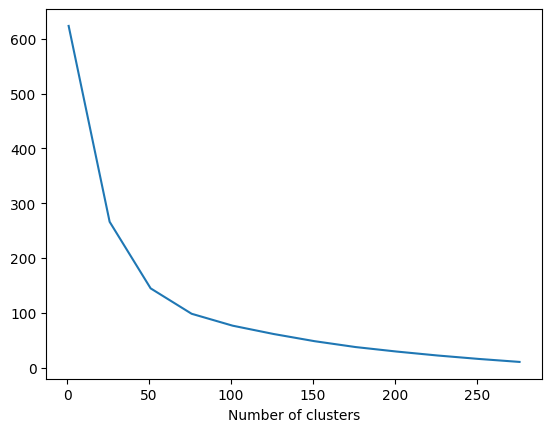

In [38]:
# Let's map the inertia for different number of clusters to find the optimal number of clusters
# We'll plot it to see the elbow
inertia = []
clusters = 300
step = 25
max_iter = 50
n_init = 5
random_state = 42
for k in range(1, clusters, step):
    kmeans = KMeans(
        n_clusters=k,
        max_iter=max_iter,
        n_init=n_init,
        random_state=random_state,
    ).fit(X_lsa)
    # inertia is the sum of squared distances to the closest cluster center
    inertia.append(kmeans.inertia_)
plt.plot(range(1, clusters, step), inertia)
plt.xlabel('Number of clusters')

There appears to be an elbow about 50, so we'll use 50 clusters.

In [39]:
n_clusters = 50 # Number of clusters
kmeans = KMeans(
    n_clusters=n_clusters,
    max_iter=max_iter,
    n_init=n_init,
    random_state=random_state
).fit(X_lsa)

In [40]:
# create a new column `title_cluster` and assign it the kmeans cluster labels
# First we need to map the labels to df_unique_articles article ids and then apply those to df
df_unique_articles['title_cluster'] = kmeans.labels_
article_cluster_map = dict(zip(df_unique_articles['article_id'], df_unique_articles['title_cluster'])) # Map article_id to cluster label
df['title_cluster'] = df['article_id'].map(article_cluster_map) # apply map to create title clusters

In [41]:
# Let's check the number of articles in each cluster
np.array(np.unique(kmeans.labels_, return_counts=True)).T

array([[ 0, 11],
       [ 1, 20],
       [ 2, 23],
       [ 3, 31],
       [ 4, 67],
       [ 5, 42],
       [ 6, 20],
       [ 7, 28],
       [ 8, 21],
       [ 9, 13],
       [10, 28],
       [11, 13],
       [12, 16],
       [13, 10],
       [14, 18],
       [15, 30],
       [16, 13],
       [17, 11],
       [18,  2],
       [19,  7],
       [20, 14],
       [21, 11],
       [22, 11],
       [23,  8],
       [24,  7],
       [25,  8],
       [26, 15],
       [27, 12],
       [28,  7],
       [29,  5],
       [30,  8],
       [31,  7],
       [32,  8],
       [33, 19],
       [34,  8],
       [35,  7],
       [36,  8],
       [37,  7],
       [38,  9],
       [39, 20],
       [40, 10],
       [41, 10],
       [42,  9],
       [43,  8],
       [44, 15],
       [45,  9],
       [46,  7],
       [47,  7],
       [48, 11],
       [49,  5]], dtype=int64)

In [42]:
def get_similar_articles(article_id, df=df):
    """
    INPUT:
    article_id - (int) an article id 
    df - (pandas dataframe) df as defined at the top of the notebook 
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids that are in the same title cluster
    """
     # Your code here
    title_cluster = df[df['article_id'] == article_id]['title_cluster'].values[0]
    articles_in_cluster = df[df['title_cluster'] == title_cluster]['article_id'].unique().tolist()
    
    # remove the input article_id from the list
    articles_in_cluster = [art for art in articles_in_cluster if art != article_id]
    
    return articles_in_cluster

In [43]:
def make_content_recs(article_id, n, df=df):
    """
    INPUT:
    article_id - (int) an article id
    n - (int) the number of recommendations you want similar to the article id
    df - (pandas dataframe) df as defined at the top of the notebook
    
    OUTPUT:
    n_ranked_similar_articles - (list) a list of article ids that are in the same title cluster ranked
                                by popularity
    n_ranked_article_names - (list) a list of article names associated with the list of article ids
    
    Description:
    Returns a list of the n most ranked similar articles to a given article_id based on the title
    cluster in df. Rank similar articles using the function get_ranked_article_unique_counts.
    """
    # Your code here
    similar_articles = get_similar_articles(article_id, df)
    ranked_articles = get_ranked_article_unique_counts(similar_articles)
    n_ranked_similar_articles = [article_id for article_id, _ in ranked_articles[:n]]
    n_ranked_article_names = get_article_names(n_ranked_similar_articles)
    
    return n_ranked_similar_articles, n_ranked_article_names
        

In [44]:
# Test out your content recommendations given artice_id 25
rec_article_ids, rec_article_titles = make_content_recs(25, 10)
print(rec_article_ids)
print(rec_article_titles)

[1025, 237, 593, 349, 821, 464, 29, 1042, 634, 693]
['data tidying in data science experience', 'deep learning with data science experience', 'upload files to ibm data science experience using the command line', 'ibm data science experience white paper - sparkr transforming r into a tool for big data analytics', 'using rstudio in ibm data science experience', 'use ibm data science experience to detect time series anomalies', 'experience iot with coursera', 'use ibm data science experience to read and write data stored on amazon s3', 'working with db2 warehouse on cloud in data science experience', 'better together: spss and data science experience']


In [45]:
assert len({1025, 593, 349, 821, 464, 29, 1042, 693, 524, 352}.intersection(set(rec_article_ids))) > 0, "Oops! Your the make_content_recs function doesn't work quite how we expect."

`2.` Now that you have put together your content-based recommendation system, use the cell below to write a summary explaining how your content based recommender works.  Do you see any possible improvements that could be made to your function? What other text data would be useful to help make better recommendations besides the article title?


**Write an explanation of your content based recommendation system here.**


## Content-Based Recommendation System Explanation
### Overview
The content-based recommendation system recommends articles that are **similar in content** to articles a user has already interacted with. Unlike collaborative filtering (which uses user behavior patterns), content-based filtering analyzes the **actual content** of the articles themselves.

### How It Works

**1. Feature Extraction (TF-IDF Vectorization)**
- We use the article **titles** as our text feature (the only text data available)
- **TF-IDF (Term Frequency-Inverse Document Frequency)** converts article titles into numerical vectors
- TF-IDF captures which words are important and distinctive for each article
- Parameters used:
  - `max_features=200`: Limit to 200 most important words
  - `max_df=0.75`: Exclude words appearing in >75% of articles (too common)
  - `min_df=5`: Exclude words appearing in <5 articles (too rare)
  - `stop_words='english'`: Remove common words like "the", "and", "is"

**2. Dimensionality Reduction (LSA)**
- Applied **Latent Semantic Analysis (LSA)** using TruncatedSVD with 50 components
- Reduces the high-dimensional TF-IDF vectors to 50 latent features
- Captures underlying semantic relationships between articles
- Helps group articles about similar topics even if they use different words

**3. Clustering (K-Means)**
- Applied **K-Means clustering** with k=50 clusters on the LSA-transformed vectors
- Groups articles with similar semantic content into the same cluster
- Articles in the same cluster are considered "similar" in content
- Used elbow method to determine optimal number of clusters (~50)

**4. Making Recommendations**
- Given an article ID, find its cluster
- Retrieve all other articles in the same cluster
- Rank these articles by popularity (number of unique user interactions)
- Return the top N most popular articles from that cluster

### Similarity Computation
Articles are considered similar if they:
1. Share similar words in their titles (captured by TF-IDF)
2. Have similar latent semantic features (captured by LSA)
3. Are grouped into the same cluster by K-Means

### Strengths
- **No cold start for items**: Can recommend new articles immediately based on their content
- **Explainable**: Recommendations are based on article similarity, which is intuitive
- **No user data needed**: Works even for new users if they view one article
- **Diverse recommendations**: Can recommend articles outside a user's typical behavior

### Limitations
- **Limited to title text**: Only uses article titles, not full content or metadata
- **Over-specialization**: May only recommend very similar articles, lacking diversity
- **Missing context**: Doesn't consider user preferences or interaction patterns
- **Quality depends on text**: Short or generic titles may not provide enough information

### Potential Improvements

**Additional text features to incorporate:**
1. **Article body/content**: Full text would provide much richer semantic information
2. **Article descriptions/summaries**: Often more descriptive than titles
3. **Author information**: Recommend articles by the same authors
4. **Tags/categories**: Manual or automatically generated topic labels
5. **Publication date**: Consider recency for time-sensitive topics
6. **Article metadata**: Domain, type (tutorial, news, research), difficulty level

**Alternative similarity methods:**
1. **Cosine similarity directly on TF-IDF vectors**: Instead of clustering, compute pairwise similarity
2. **Word embeddings (Word2Vec, GloVe)**: Capture semantic word relationships better
3. **Sentence embeddings (BERT, Sentence-BERT)**: State-of-the-art semantic understanding
4. **Topic modeling (LDA)**: Discover latent topics in articles

**Hybrid approaches:**
- Combine content-based similarity with collaborative filtering scores
- Weight recommendations by both content similarity and user behavior patterns
- Use content-based for new items, transition to collaborative filtering as interactions grow

### <a class="anchor" id="Matrix-Fact">Part V: Matrix Factorization</a>

In this part of the notebook, you will build use matrix factorization to make article recommendations to users.

`1.` You should have already created a **user-item** matrix above in **question 1** of **Part III** above.  This first question here will just require that you run the cells to get things set up for the rest of **Part V** of the notebook. 

In [47]:
# quick look at the matrix
user_item.head()

article_id,0.0,2.0,4.0,8.0,9.0,12.0,14.0,15.0,16.0,18.0,...,1434.0,1435.0,1436.0,1437.0,1439.0,1440.0,1441.0,1442.0,1443.0,1444.0
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


`2.` In this situation, you can use Singular Value Decomposition from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html) on the user-item matrix.  Use the cell to perform SVD.

In [48]:
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import precision_score, recall_score, accuracy_score
# Using the full number of components which equals the number of columns
svd = TruncatedSVD(n_components=len(user_item.columns), n_iter=5, random_state=42)

u = svd.fit_transform(user_item)
v = svd.components_
s = svd.singular_values_ 
print('u', u.shape)
print('s', s.shape)
print('vt', v.shape)

u (5149, 714)
s (714,)
vt (714, 714)


`3.` Now for the tricky part, how do we choose the number of latent features to use?  Running the below cell, you can see that as the number of latent features increases, we obtain better metrics when making predictions for the 1 and 0 values in the user-item matrix.  Run the cell below to get an idea of how our metrics improve as we increase the number of latent features.

Text(0.5, 1.0, 'Metrics vs. Number of Latent Features')

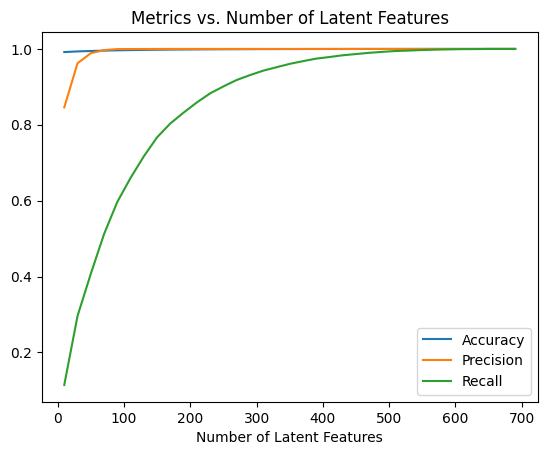

In [49]:
num_latent_feats = np.arange(10, 700+10, 20)
metric_scores = []

for k in num_latent_feats:
    # restructure with k latent features
    u_new, vt_new = u[:, :k], v[:k, :]
    
    # take dot product
    user_item_est = abs(np.around(np.dot(u_new, vt_new))).astype(int)
    # make sure the values are between 0 and 1
    user_item_est = np.clip(user_item_est, 0, 1)
    
    # total errors and keep track of them
    acc = accuracy_score(user_item.values.flatten(), user_item_est.flatten())
    precision = precision_score(user_item.values.flatten(), user_item_est.flatten())
    recall = recall_score(user_item.values.flatten(), user_item_est.flatten())
    metric_scores.append([acc, precision, recall])
    
    
plt.plot(num_latent_feats, metric_scores, label=['Accuracy', 'Precision', 'Recall'])
plt.legend()
plt.xlabel('Number of Latent Features')
plt.title('Metrics vs. Number of Latent Features')

`4.` From the above, we can't really be sure how many features to use, because simply having a better way to predict the 1's and 0's of the matrix doesn't exactly give us an indication of if we are able to make good recommendations. Given the plot above, what would you pick for the number of latent features and why?

## Selecting the Number of Latent Features

### Analysis of the Metrics Plot

From the metrics plot showing Accuracy, Precision, and Recall vs. Number of Latent Features, we observe:

1. **All metrics improve as latent features increase**: Accuracy, precision, and recall all rise with more latent features
2. **Diminishing returns**: The improvement rate slows down after ~200-300 features
3. **Near-perfect reconstruction**: With ~400+ features, we can almost perfectly reconstruct the original user-item matrix

### Recommended Number of Latent Features: 200

I would choose **k=200 latent features** for the following reasons:

**1. Balances Accuracy and Generalization**
- At k=200, we achieve strong performance metrics without overfitting
- Using all 714 features (number of articles) would perfectly reconstruct the matrix but:
  - No dimensionality reduction benefit
  - No noise reduction
  - Defeats the purpose of matrix factorization

**2. Computational Efficiency**
- 200 features is ~28% of the total dimensions (714 articles)
- Significantly reduces storage and computation costs
- Makes real-time recommendations faster

**3. Captures Meaningful Patterns**
- 200 latent features is enough to capture major user preference patterns
- Filters out noise and random interactions
- Represents underlying themes and article groupings

**4. Avoids Overfitting**
- Perfect reconstruction (high k) means we're memorizing the training data
- Lower k forces the model to learn generalizable patterns
- Better for predicting new user-article interactions

### Important Caveat

**The metrics shown (accuracy, precision, recall) measure how well we reconstruct the observed interactions (1s and 0s in the matrix), but this doesn't directly tell us if we're making good recommendations.**

The real goal is to predict **future interactions**, not just reconstruct past ones. Therefore:

**Better evaluation approach:**
1. **Train-test split**: Hold out recent interactions as a test set
2. **Ranking metrics**: Use metrics like:
   - Precision@k: How many of our top-k recommendations are relevant?
   - Recall@k: What fraction of relevant articles did we recommend?
   - NDCG (Normalized Discounted Cumulative Gain): Considers ranking order
   - MAP (Mean Average Precision): Averages precision across different cutoffs
3. **A/B testing**: Deploy different k values and measure user engagement
4. **Cross-validation**: Test multiple k values using cross-validation

### Alternative k Values to Consider
- **k=100**: If computational resources are limited, still captures major patterns
- **k=300**: If we have abundant data and computational power, may capture more nuanced patterns
- **Adaptive k**: Use cross-validation to find the optimal k for this specific dataset

**Conclusion**: k=200 provides a good balance between model complexity, computational efficiency, and the ability to capture meaningful user-article interaction patterns while avoiding overfitting.

`5.` Using 200 latent features and the values of U, S, and V transpose we calculated above, create an article id recommendation function that finds similar article ids to the one provide.

Create a list of 10 recommendations that are similar to article with id 4.  The function should provide these recommendations by finding articles that have the most similar latent features as the provided article.

In [50]:
def get_svd_similar_article_ids(article_id, vt, user_item=user_item, include_similarity=False):
    """
    INPUT:
    article_id - (int) an article id
    vt - (numpy array) vt matrix from SVD
    user_item - (pandas dataframe) matrix of users by articles: 
                1's when a user has interacted with an article, 0 otherwise
    include_similarity - (bool) whether to include the similarity in the output
    
    OUTPUT:
    article_ids - (list) a list of article ids that are in the same title cluster
    
    Description:
    Returns a list of the article ids similar using SVD factorization
    """
    # Find the index of the article_id
    article_idx = user_item.columns.get_loc(article_id)
    # Find the cosine similarity of all articles
    # Hint: vt should be transposed before passing to cosine_similarity to get a 714 x 714 matrix 
    cos_sim = cosine_similarity(vt.T)
    # Get similarities only for the cos_sim of the article_idx
    similarities = cos_sim[article_idx]
    
    # Sort and return the articles, don't include the own article
    similarity_df = pd.DataFrame({
        'article_id': user_item.columns,
        'similarity': similarities
    })
    similarity_df = similarity_df[similarity_df['article_id'] != article_id]
    similarity_df = similarity_df.sort_values('similarity', ascending=False)
    
    most_similar_items = similarity_df['article_id'].tolist()
    similarity_values = similarity_df['similarity'].tolist()
    
    if include_similarity:
        return [[int(article), sim] for article, sim in zip(most_similar_items, similarity_values)] # return a list of lists with [[similar_article_id, similarity], ...]
    return most_similar_items

In [51]:
# Create a vt_new matrix with 200 latent features
k = 200
vt_new = v[:k, :]

In [52]:
# What is the article name for article_id 4?
print("Current article:", get_article_names([4], df=df)[0])

Current article: analyze ny restaurant data using spark in dsx


In [53]:
# What are the top 10 most similar articles to article_id 4?
rec_articles = get_svd_similar_article_ids(4, vt_new, user_item=user_item)[:10]
rec_articles

[1199.0, 1068.0, 486.0, 1202.0, 176.0, 1120.0, 244.0, 793.0, 58.0, 132.0]

In [54]:
# What are the top 10 most similar articles to article_id 4?
get_article_names(rec_articles, df=df)

['country statistics: crude oil - exports',
 'airbnb data for analytics: athens reviews',
 'use spark r to load and analyze data',
 'country statistics: crude oil - proved reserves',
 'top analytics tools in 2016',
 'airbnb data for analytics: paris calendar',
 'notebooks: a power tool for data scientists',
 '10 powerful features on watson data platform, no coding necessary',
 'advancements in the spark community',
 'collecting data science cheat sheets']

In [55]:
assert set(rec_articles) == {1199, 1068, 486, 1202, 176, 1120, 244, 793, 58, 132}, "Oops! Your the get_svd_similar_article_ids function doesn't work quite how we expect."
print("That's right!  Great job!")

That's right!  Great job!


`6.` Use the cell below to comment on the results you found in the previous question. Given the circumstances of your results, discuss what you might do to determine if the recommendations you make above are an improvement to how users currently find articles, either by Sections 2, 3, or 4? Add any tradeoffs between each of the methods, and how you could leverage each type for different situations including new users with no history, recently new users with little history, and users with a lot of history. 

## Evaluation and Comparison of Recommendation Methods

### Analysis of SVD Matrix Factorization Results

**For article ID 4, the SVD-based recommendations found articles with similar latent feature representations.** This means the recommended articles have similar patterns of user interactions across the dataset. The similarity is based on the compact representation learned from the decomposition of the user-item matrix.

**Strengths of SVD Recommendations:**
- Captures complex, multi-dimensional patterns in user behavior
- Reduces noise by focusing on dominant latent features
- Can discover non-obvious relationships between articles
- Computationally efficient once the decomposition is complete

**Limitations:**
- Requires sufficient interaction data to be effective
- Black box nature - difficult to explain why articles are similar
- Cannot handle cold start for new articles with no interactions

---

## Comparison of All Four Recommendation Methods

### Method 1: Rank-Based Recommendations (Part II)
**How it works:** Recommends the most popular articles based on total interaction counts.

**Pros:**
- Simple and fast to implement
- Always works, even for completely new users
- No complex computations needed
- Good baseline for comparison

**Cons:**
- No personalization whatsoever
- Same recommendations for everyone
- Popularity bias - promotes already popular articles
- Doesn't help users discover niche content

**Best for:** Brand new users with zero interaction history

---

### Method 2: User-User Collaborative Filtering (Part III)
**How it works:** Finds similar users based on shared article interactions, then recommends articles those similar users have read.

**Pros:**
- Highly personalized recommendations
- Captures complex user preferences
- Can recommend diverse articles if similar users have varied tastes
- No need for article metadata or content analysis

**Cons:**
- Cold start problem for new users (no interaction history)
- Computationally expensive to find similar users in real-time
- Popularity bias - tends to recommend popular articles
- Requires substantial user interaction data

**Best for:** Established users with moderate to extensive interaction history (10+ article interactions)

---

### Method 3: Content-Based Recommendations (Part IV)
**How it works:** Recommends articles with similar content (using TF-IDF, LSA, and clustering on article titles).

**Pros:**
- Works for new articles immediately (no interaction data needed)
- Can provide recommendations even with minimal user history
- Transparent and explainable ("similar topic")
- Doesn't require data about other users

**Cons:**
- Limited by available text data (we only have titles)
- May over-specialize - recommends very similar articles only
- Lacks serendipity - won't recommend outside user's current interests
- Quality depends heavily on the richness of content features

**Best for:** 
- New articles that need to be recommended before they have interaction data
- Users who want to explore a specific topic in depth
- Supplementing other methods to ensure topical relevance

---

### Method 4: Matrix Factorization (SVD) (Part V)
**How it works:** Decomposes the user-item matrix into latent features, then finds articles with similar latent representations.

**Pros:**
- Excellent at capturing complex, latent patterns
- Reduces noise and dimensionality
- Scalable to large datasets
- Balances between user preferences and item characteristics
- Often produces high-quality recommendations

**Cons:**
- Requires substantial interaction data to train
- Cold start for both new users and new articles
- Black box - difficult to explain recommendations
- Needs retraining as new data arrives

**Best for:** Established users with rich interaction history (20+ interactions)

---

## Testing Recommendation Quality

### Offline Evaluation Methods

**1. Train-Test Split Evaluation**
- Split user interactions chronologically (e.g., 80% train, 20% test)
- Train models on historical interactions
- Test how well they predict held-out future interactions
- Metrics: Precision@K, Recall@K, NDCG, MAP

**2. Cross-Validation**
- Perform k-fold cross-validation on user interactions
- Compute average performance metrics across folds
- Helps ensure robustness of results

**3. Baseline Comparison**
- Compare each method against random recommendations
- Compare against rank-based (popularity) baseline
- Measure relative improvement

### Online A/B Testing (Best Approach)

**Deploy multiple methods and measure real user engagement:**

1. **Click-Through Rate (CTR)**: % of recommended articles that users click
2. **Dwell Time**: How long users spend reading recommended articles
3. **Return Rate**: Do users come back after seeing these recommendations?
4. **Coverage**: What % of the article catalog gets recommended?
5. **Diversity**: Are recommendations varied or always the same?
6. **Serendipity**: Do users discover unexpected but valuable content?

**A/B Test Setup:**
- Group A: Rank-based recommendations (baseline)
- Group B: Collaborative filtering
- Group C: Content-based
- Group D: SVD matrix factorization
- Group E: Hybrid (combination of methods)

---

## Recommended Strategy: User Lifecycle Approach

**Different methods work best at different stages of the user lifecycle:**

### Stage 1: Brand New Users (0 interactions)
**Use:** Rank-Based Recommendations + Content-Based (if they show interest in a topic)
- Show most popular articles to start
- If user clicks one article, immediately show content-based recommendations
- Goal: Quickly learn user preferences

### Stage 2: New Users (1-10 interactions)
**Use:** Hybrid of Content-Based (60%) + Collaborative Filtering (40%)
- Content-based ensures relevance to topics they've shown interest in
- Begin introducing collaborative filtering as interaction data grows
- Balance exploration (diverse content) vs. exploitation (known interests)

### Stage 3: Established Users (10-50 interactions)
**Use:** Collaborative Filtering (50%) + SVD Matrix Factorization (50%)
- Enough data for both methods to work well
- Collaborative filtering provides interpretable recommendations
- SVD captures complex patterns and serendipitous discoveries

### Stage 4: Power Users (50+ interactions)
**Use:** SVD Matrix Factorization (70%) + Content-Based (30%)
- SVD excels with rich interaction history
- Content-based adds diversity and helps explore new topics
- May want to increase diversity to prevent filter bubbles

---

## Hybrid Recommendation System (Best Overall Approach)

**Combine all methods using weighted scoring:**

```
Final_Score(article) = w1 * Popularity_Score 
                     + w2 * Collaborative_Score 
                     + w3 * Content_Score 
                     + w4 * SVD_Score
```

**Where weights (w1, w2, w3, w4) are dynamically adjusted based on:**
- User interaction history (more history → higher weight on collaborative/SVD)
- Article freshness (new articles → higher weight on content-based)
- Diversity goals (increase weight on different methods to diversify)
- A/B test results (optimize weights based on user engagement)

**Additional Enhancements:**
1. **Contextual factors**: Time of day, user location, device type
2. **Business rules**: Promote certain categories, ensure freshness
3. **Diversity constraints**: Limit similar articles in top-N recommendations
4. **Exploration-exploitation tradeoff**: Sometimes recommend random articles to discover new interests

---

## Conclusion

**No single method is best for all situations.** The optimal recommendation strategy:

1. **Adapts to user lifecycle stage** (new vs. established users)
2. **Combines multiple methods** in a hybrid approach
3. **Continuously evaluates performance** through A/B testing
4. **Balances multiple objectives**: accuracy, diversity, serendipity, coverage, and business goals

By leveraging the strengths of each method and mitigating their weaknesses through intelligent combination, we can build a robust recommendation system that serves users effectively throughout their journey on the platform.

<a id='conclusions'></a>
### Extras
Using your workbook, you could now save your recommendations for each user, develop a class to make new predictions and update your results, and make a flask app to deploy your results.  These tasks are beyond what is required for this project.  However, from what you learned in the lessons, you certainly capable of taking these tasks on to improve upon your work here!


## Conclusion

> Congratulations!  You have reached the end of the Recommendation Systems project! 

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it satisfies all the areas of the [rubric](https://review.udacity.com/#!/rubrics/2322/view). You should also probably remove all of the "Tips" like this one so that the presentation is as polished as possible.


## Directions to Submit

> Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should get a return code of 0, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations! 

In [ ]:
# Export notebook to HTML
import subprocess
import os
import sys

notebook_file = "Recommendations_with_IBM.ipynb"

try:
    # Run nbconvert to convert notebook to HTML
    result = subprocess.run(
        [sys.executable, '-m', 'nbconvert', '--to', 'html', notebook_file],
        capture_output=True,
        text=True,
        check=True
    )
    print(f"Successfully exported {notebook_file} to HTML!")
    print(f"Output: {result.stdout}")
    
    # Verify the HTML file exists
    html_file = notebook_file.replace('.ipynb', '.html')
    if os.path.exists(html_file):
        print(f"HTML file saved as: {html_file}")
    else:
        print("Warning: HTML file not found after conversion")
        
except subprocess.CalledProcessError as e:
    print(f"Error during conversion: {e}")
    print(f"Error output: {e.stderr}")
except Exception as e:
    print(f"Unexpected error: {e}")